In [22]:
from preprocessing_class import Preprocessing, load_movies, load_pres
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.model_selection import StratifiedShuffleSplit, train_test_split
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC,SVC
from nltk.corpus import stopwords
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import TruncatedSVD
from sklearn.manifold import TSNE
from sklearn.decomposition import LatentDirichletAllocation
import numpy as np
import string
import matplotlib.pyplot as plt
import json
import pandas as pd
import seaborn as sns
from pathlib import Path

sns.set_style("darkgrid")


# config
DATASET = "pres"

if DATASET == "movies": lang = "en"
else: lang = "fr"

STOPWORDS_FR = stopwords.words('french')
STOPWORDS_EN = stopwords.words('english')
STOPWORDS = STOPWORDS_FR if DATASET == "pres" else STOPWORDS_EN

RANDOM_STATE = 42
TEST_SIZE = 0.20
MAX_FEATURE = 5000
SAVING_FILE_NAME =  DATASET + "_ldalsa_"

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
def load_data(data_path, test_size=TEST_SIZE):
    print(data_path)
    print("DATASET ", DATASET)

    if DATASET == "pres":
        # Load and convert labels
        alltxt, alllabs = load_pres(data_path)
        alltxt = np.array(alltxt)
        # Convert labels: 1 -> 0, -1 -> 1
        alllabs = np.where(np.array(alllabs) == 1, 0, 1)
        
        print(f"Size train: {len(alltxt)}")
    else:
        alltxt,alllabs = load_movies(data_path)
        alltxt, alllabs = np.array(alltxt), np.array(alllabs)
        print(f"Size train: {len(alltxt)}")
    print(f"len: {len(alltxt)}, unique labels: {np.unique(alllabs)}")
    return alltxt, alllabs

In [24]:
path =  "Dataset/corpus.tache1.learn.utf8" if DATASET == "pres" else "./Dataset/movies1000/"
alltxt,alllabs = load_data(path)

Dataset/corpus.tache1.learn.utf8
DATASET  pres
Size train: 57413
len: 57413, unique labels: [0 1]


In [25]:
punc = set(string.punctuation + '\n\r\t')
punc.remove("'") # keep the ' for french words 
custom_punctuation = "".join(punc)

prep = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = False,
                word_norm = None, # stem faster
                pos_tagging = False, # to check
                all_capital = True, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "english" if DATASET == "movies" else "french",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

def stopwords_rmv(text, stopwords=STOPWORDS):
    return " ".join([word for word in text.split() if word not in stopwords])

alltxt = [stopwords_rmv(t) for t in alltxt]
alltxt[:1]
#alltxt = [prep(t).split() for t in alltxt]


["Quand dis chers amis, s'agit là d'une formule diplomatique, l'expression ressens."]

# 2) Latent Semantic Analysis (LSA <=> SVD)


**Remember the LSA factorziation**:
$$
\begin{matrix}
 & X  &\!\!\!\!\!=\!\!\!\!\!& U  & \Sigma & V^T \\
  & \textbf{t}_j   &  & \hat{ \textbf{d}_i} & &  \\
 & \downarrow  &  &\downarrow  & & \\
\textbf{d}_i \rightarrow
&
\begin{pmatrix}
x_{1,1} & \dots & x_{1,d} \\
\\
\vdots & \ddots & \vdots \\
\\
x_{N,1} & \dots & x_{N,d} \\
\end{pmatrix}
&
\!\!\!\!\!=\!\!\!\!\!
%&
%(\hat{ \textbf{t}_j}) \rightarrow
&
\begin{pmatrix}
\begin{pmatrix} &  \textbf{u}_1 &  \end{pmatrix} \\
\vdots \\
\begin{pmatrix}  & \textbf{u}_k &  \end{pmatrix}
\end{pmatrix}
%&
%\!\!\!\!\!\cdot\!\!\!\!\!
&
\begin{pmatrix}
\sigma_1 & \dots & 0 \\
\vdots & \ddots & \vdots \\
0 & \dots & \sigma_k \\
\end{pmatrix}
%&
%\!\!\!\!\!\cdot\!\!\!\!\!
&
\begin{pmatrix}
\begin{pmatrix} \, \\ \, \\ \textbf{v}_1 \\ \, \\ \,\end{pmatrix}
\dots
\begin{pmatrix} \, \\ \, \\ \textbf{v}_k \\ \, \\ \, \end{pmatrix}
\end{pmatrix}
\end{matrix}
$$

- Look at [SVD doc in skelarn](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.TruncatedSVD.html#sklearn.decomposition.TruncatedSVD)
- Do the same qualitative/quantitative evaluation than with K-Means
- You can also use LSA as a pre-processing step for K-Means, *i.e.* running K-Means on $\boldsymbol{U}$ matrix above
    - N.B. : try without/with $\ell_2$ normalization of $\boldsymbol{U}$'s rows before running  K-Means
    - You can also benefit from LSA pre-processing for using [t-SNE visualization](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) (see code below)


In [ ]:
vectorizer = TfidfVectorizer(
    max_features=5000,    # limit vocab size
    min_df=2,             # ignore rare words
    max_df=0.95,          # ignore super common words
    stop_words=STOPWORDS,
    ngram_range=(1,2)     # unigrams + bigrams
)
vectors = vectorizer.fit_transform(alltxt)

n_topics = 100
svd = TruncatedSVD(n_components=n_topics, n_iter=15, random_state=42)
U = svd.fit_transform(vectors)  # document-topic matrix
S = svd.singular_values_        # singular values

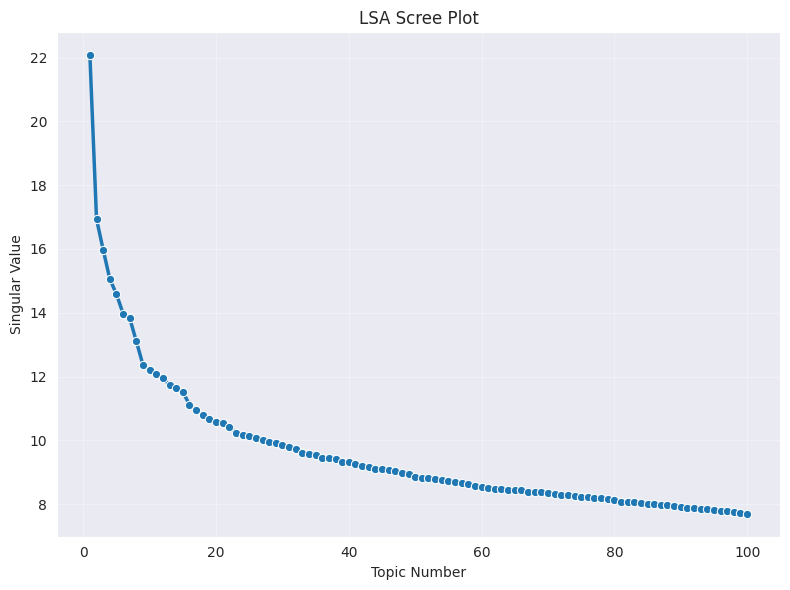

In [27]:
fig, axes = plt.subplots(figsize=(8,6))

# scree plot
sns.lineplot(x=range(1, n_topics+1), y=S[:n_topics], marker='o', 
             linewidth=2.5, markersize=6)
axes.set_xlabel('Topic Number')
axes.set_ylabel('Singular Value')
axes.set_title('LSA Scree Plot')
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'lsa_{DATASET}_scree.pdf', dpi=300, bbox_inches='tight')
plt.show()

### MOVIES

In [ ]:
n_topics = 40
svd = TruncatedSVD(n_components=n_topics, n_iter=15, random_state=42)
U = svd.fit_transform(vectors)  # document-topic matrix
S = svd.singular_values_        # singular values

print(f"Explained variance ratio: {svd.explained_variance_ratio_.sum():.3f}")

# --- Step 2: Find top words per topic ---
feat_names = vectorizer.get_feature_names_out()
topic_term_matrix = svd.components_  # topic x terms

for i in range(min(10, n_topics)):  # top 10 topics
    top_indices = np.argsort(np.abs(topic_term_matrix[i]))[::-1][:10]
    top_words = [feat_names[idx] for idx in top_indices]
    print(f"Topic {i}: {', '.join(top_words)}")


# --- Step 3: KMeans clustering on topic space ---
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(U)
cluster_centers = kmeans.cluster_centers_

scaler = StandardScaler()
U_scaled = scaler.fit_transform(U)

tsne = TSNE(
    n_components=2,
    perplexity=5,        # good for your dataset size
    learning_rate=200,
    max_iter=2000,
    init='pca',
    random_state=42,
    method='exact'        # better quality
)
tsne_mat = tsne.fit_transform(U_scaled)


Explained variance ratio: 0.091
Topic 0: plus, france, hui, aujourd, aujourd hui, cette, pays, aussi, nom, être
Topic 1: hui, aujourd, aujourd hui, nom, plus, aussi, être, france, cette, pays
Topic 2: messieurs, mesdames, mesdames messieurs, monsieur, président, monsieur président, plus, nom, être, doit
Topic 3: nom, plus, messieurs, mesdames, mesdames messieurs, france, président, nom nom, plus plus, être
Topic 4: plus, nom, être, doit, doit être, plus plus, france, cette, peut, nom nom
Topic 5: nom, être, monsieur, président, monsieur président, doit, france, doit être, messieurs, mesdames messieurs
Topic 6: france, monsieur, président, monsieur président, être, doit, doit être, plus, messieurs, mesdames messieurs
Topic 7: france, aussi, être, faut, tout, doit, plus, cela, bien, doit être
Topic 8: pays, tout, france, cela, bien, cette, deux, europe, faut, entre
Topic 9: aussi, tout, pays, cela, fait, faut, deux, tout cela, tout fait, heure


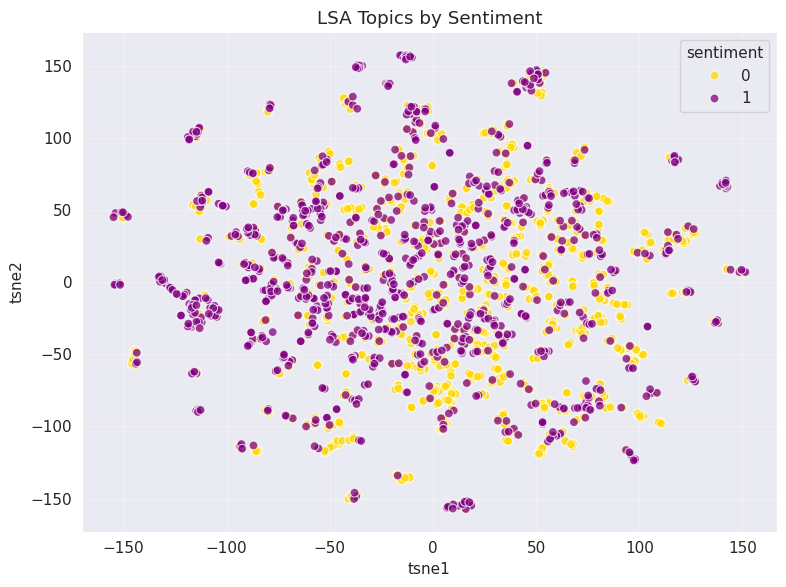

In [ ]:
df_vis = pd.DataFrame({
    'tsne1': tsne_mat[:, 0],
    'tsne2': tsne_mat[:, 1],
    'sentiment': alllabs,
    'cluster': cluster_labels
})

fig, axes = plt.subplots(figsize=(8,6))

#by labels
sns.scatterplot(data=df_vis, x='tsne1', y='tsne2', hue='sentiment', 
                palette=['gold', 'purple'], s=40, alpha=0.75, 
                edgecolor='white', linewidth=0.8)
axes.set_title('LSA Topics by Sentiment')
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'lsa_{DATASET}_topics_sentiment.pdf', dpi=300, bbox_inches='tight')
plt.show()

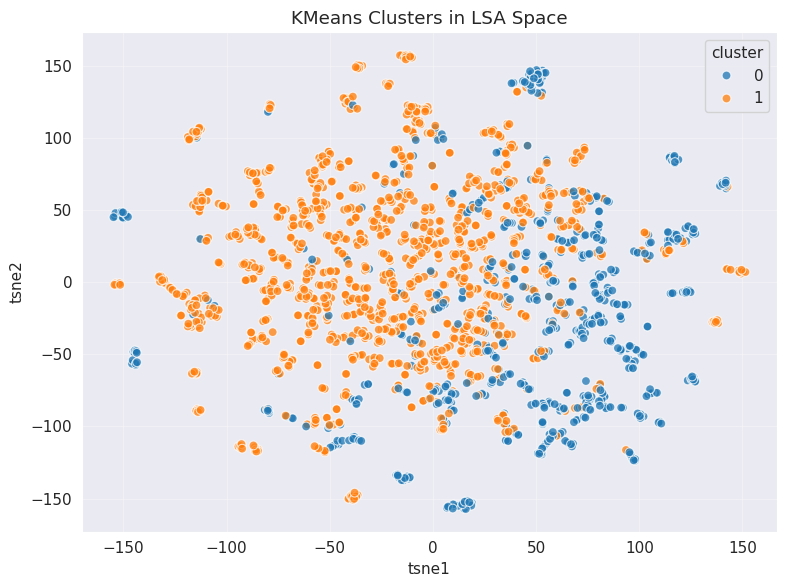

In [ ]:
fig, axes = plt.subplots(figsize=(8,6))

# kmeans
sns.scatterplot(data=df_vis, x='tsne1', y='tsne2', hue='cluster', 
                palette='tab10', s=40, alpha=0.75, 
                edgecolor='white', linewidth=0.8)
axes.set_title('KMeans Clusters in LSA Space')
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'lsa_{DATASET}_topics_kmeans.pdf', dpi=300, bbox_inches='tight')
plt.show()

### PRES

In [28]:
n_topics = 20 
svd = TruncatedSVD(n_components=n_topics, n_iter=15, random_state=42)
U = svd.fit_transform(vectors)  # document-topic matrix
S = svd.singular_values_        # singular values

print(f"Explained variance ratio: {svd.explained_variance_ratio_.sum():.3f}")

# --- Step 2: Find top words per topic ---
feat_names = vectorizer.get_feature_names_out()
topic_term_matrix = svd.components_  # topic x terms

for i in range(min(10, n_topics)):  # top 10 topics
    top_indices = np.argsort(np.abs(topic_term_matrix[i]))[::-1][:10]
    top_words = [feat_names[idx] for idx in top_indices]
    print(f"Topic {i}: {', '.join(top_words)}")


# --- Step 3: KMeans clustering on topic space ---
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(U)
cluster_centers = kmeans.cluster_centers_

scaler = StandardScaler()
U_scaled = scaler.fit_transform(U)

tsne = TSNE(
    n_components=2,
    perplexity=5,        # good for your dataset size
    learning_rate=200,
    max_iter=2000,
    init='pca',
    random_state=42,
)
tsne_mat = tsne.fit_transform(U_scaled)


Explained variance ratio: 0.057
Topic 0: plus, france, hui, aujourd, aujourd hui, cette, pays, aussi, nom, être
Topic 1: hui, aujourd, aujourd hui, nom, plus, aussi, être, france, cette, pays
Topic 2: messieurs, mesdames, mesdames messieurs, monsieur, président, monsieur président, plus, nom, être, doit
Topic 3: nom, plus, messieurs, mesdames, mesdames messieurs, france, président, nom nom, plus plus, être
Topic 4: plus, nom, être, doit, doit être, plus plus, france, cette, peut, nom nom
Topic 5: nom, être, monsieur, président, monsieur président, doit, france, doit être, messieurs, mesdames messieurs
Topic 6: france, monsieur, président, monsieur président, être, doit, doit être, plus, messieurs, mesdames messieurs
Topic 7: france, aussi, être, faut, tout, doit, plus, cela, bien, doit être
Topic 8: pays, tout, france, cela, bien, cette, deux, europe, entre, faut
Topic 9: aussi, tout, pays, cela, fait, faut, deux, tout cela, tout fait, heure


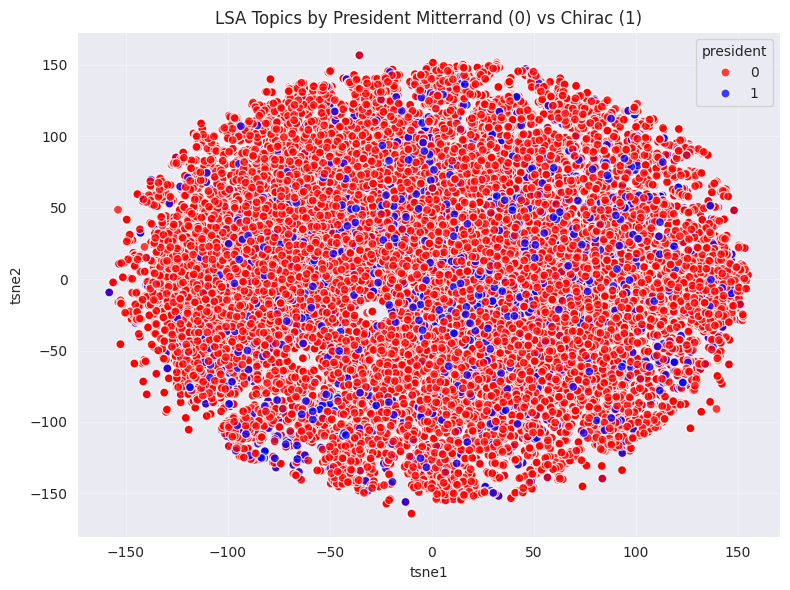

In [29]:
df_vis = pd.DataFrame({
    'tsne1': tsne_mat[:, 0],
    'tsne2': tsne_mat[:, 1],
    'president': alllabs, 
    'cluster': cluster_labels
})

fig, axes = plt.subplots(figsize=(8,6))

sns.scatterplot(data=df_vis, x='tsne1', y='tsne2', hue='president', 
                palette=['red', 'blue'], s=40, alpha=0.75,  # Changed colors
                edgecolor='white', linewidth=0.8)
axes.set_title('LSA Topics by President Mitterrand (0) vs Chirac (1)')  # Changed title
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'lsa_presidents_topics_speakers.pdf', dpi=300, bbox_inches='tight')  # Changed filename
plt.show()

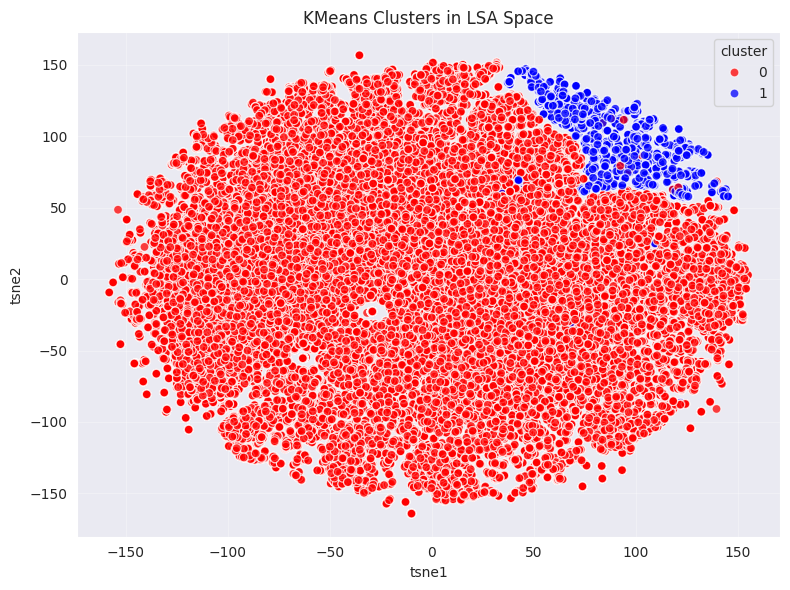

In [31]:
fig, axes = plt.subplots(figsize=(8,6))

# kmeans
sns.scatterplot(data=df_vis, x='tsne1', y='tsne2', hue='cluster', 
                palette=['red', 'blue'], s=40, alpha=0.75, 
                edgecolor='white', linewidth=0.8)
axes.set_title('KMeans Clusters in LSA Space')
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'lsa_{DATASET}_topics_kmeans.pdf', dpi=300, bbox_inches='tight')
plt.show()

# 3) Latent Dirichlet Allocation (LDA)

**Start with a CountVectorizer**

### MOVIES

In [ ]:
from nltk.tokenize import RegexpTokenizer

#tokenizer = RegexpTokenizer(r'\w+')
n_topics = 15
vectorizer = CountVectorizer(
    lowercase=True, stop_words=STOPWORDS, ngram_range=(1,2),
    tokenizer=RegexpTokenizer(r'\w+').tokenize, 
    max_df=0.95, min_df=2, max_features=5000
)

vectors = vectorizer.fit_transform(alltxt)
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, max_iter=20)
M = lda.fit_transform(vectors)  # document-topic matrix (probabilities)

feat_names = vectorizer.get_feature_names_out()
for i, topic in enumerate(lda.components_):
    top_words = [feat_names[j] for j in np.argsort(topic)[-10:][::-1]]
    print(f"Topic {i}: {', '.join(top_words)}")

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(M)

scaler = StandardScaler()
M_scaled = scaler.fit_transform(M)
tsne = TSNE(n_components=2, perplexity=30, random_state=42,max_iter=2000)
tsne_mat = tsne.fit_transform(M_scaled)



/home/alant/repos/tal-projet/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Topic 0: film, one, good, character, movie, like, get, time, much, also
Topic 1: film, one, life, story, like, man, character, two, characters, love
Topic 2: disney, story, city, tarzan, new, animated, animation, godzilla, toy, film
Topic 3: movie, film, one, like, bad, even, good, really, get, see
Topic 4: film, horror, one, scream, batman, movie, first, films, trek, 2
Topic 5: kevin, film, movie, good, affleck, smith, patch, jay, williams, bacon
Topic 6: film, one, movie, comedy, like, funny, even, characters, harry, two
Topic 7: movie, film, one, hollywood, like, great, ryan, life, flynt, would
Topic 8: film, tarantino, vegas, jackie, pulp, bond, fiction, pulp fiction, one, wild
Topic 9: film, mars, carter, planet, 4, mission, space, earth, species, apes
Topic 10: film, one, movie, like, little, family, good, life, joe, even
Topic 11: star, wars, film, star wars, van, lucas, phantom, menace, van damme, damme
Topic 12: movie, murphy, gibson, one, mel, big, like, troopers, blade, run


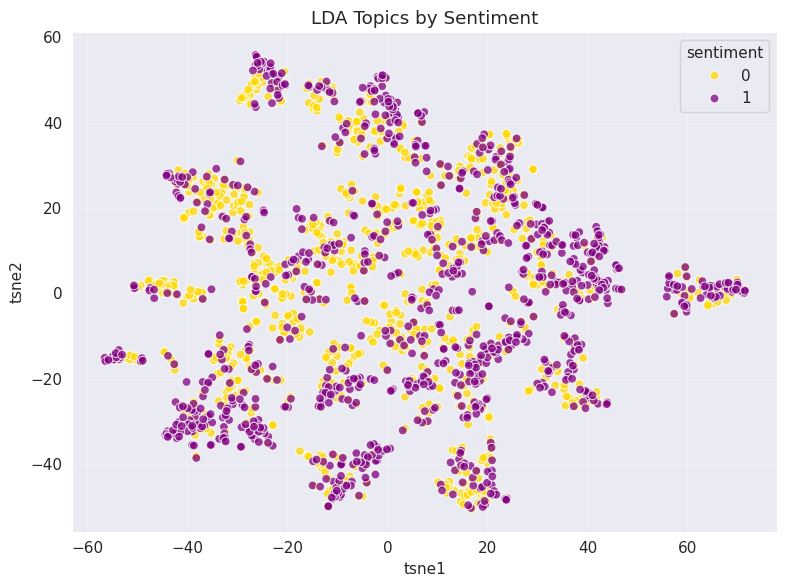

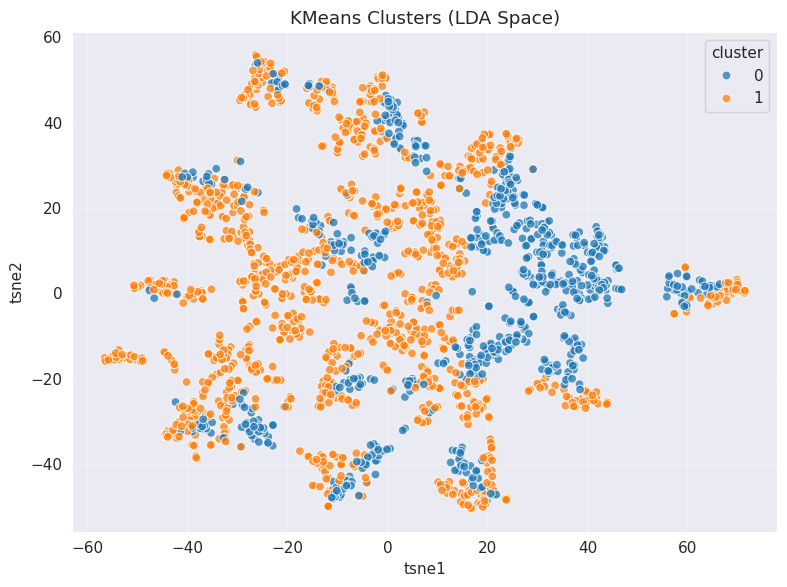

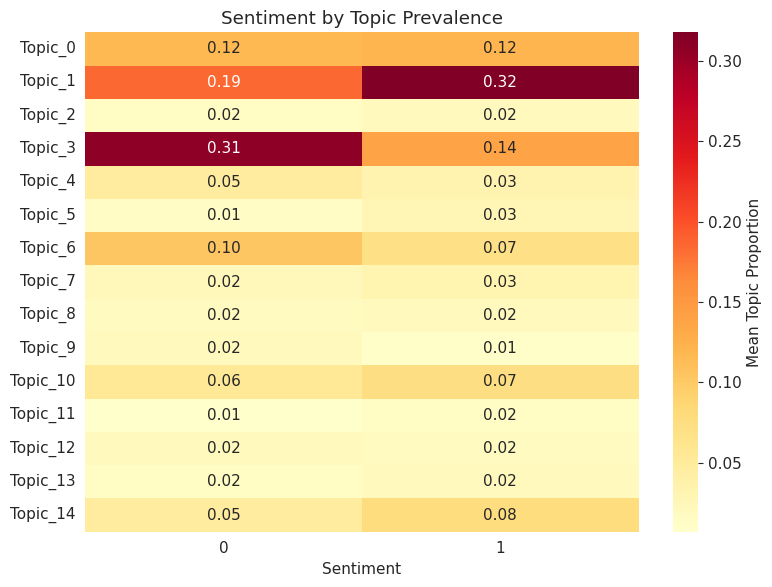

In [ ]:
df_vis = pd.DataFrame({
    'tsne1': tsne_mat[:, 0],
    'tsne2': tsne_mat[:, 1],
    'president': alllabs,
    'cluster': cluster_labels,
    'dominant_topic': np.argmax(M, axis=1)
})

fig, axes = plt.subplots(figsize=(8,6))

sns.scatterplot(data=df_vis, x='tsne1', y='tsne2', hue='sentiment', 
                palette=['gold', 'purple'], s=40, alpha=0.75, 
                edgecolor='white', linewidth=0.8)
axes.set_title('LDA Topics by Sentiment')
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'lda_{DATASET}_topics_sentiment.pdf', dpi=300, bbox_inches='tight')
plt.show()

fig, axes = plt.subplots(figsize=(8,6))


# 2. MIDDLE: KMeans clusters
sns.scatterplot(data=df_vis, x='tsne1', y='tsne2', hue='cluster', 
                palette='tab10', s=40, alpha=0.75, 
                edgecolor='white', linewidth=0.8)
axes.set_title('KMeans Clusters (LDA Space)')
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'lda_{DATASET}_topics_kmeans.pdf', dpi=300, bbox_inches='tight')
plt.show()



fig, axes = plt.subplots(figsize=(8,6))
# 3. RIGHT: Topic prevalence heatmap
topic_props = pd.DataFrame(M, columns=[f'Topic_{i}' for i in range(n_topics)])
topic_sent = topic_props.join(pd.Series(alllabs, name='sentiment')).groupby('sentiment')[topic_props.columns].mean()
sns.heatmap(topic_sent.T, annot=True, fmt='.2f', cmap='YlOrRd', 
            cbar_kws={'label': 'Mean Topic Proportion'})
axes.set_title('Sentiment by Topic Prevalence')
axes.set_xlabel('Sentiment')

plt.tight_layout()
plt.savefig(f'lda_{DATASET}_sentiment_topic.pdf', dpi=300, bbox_inches='tight')
plt.show()


/tmp/ipykernel_28346/1672620073.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_prevalence, x='topic', y='prevalence', palette='viridis')


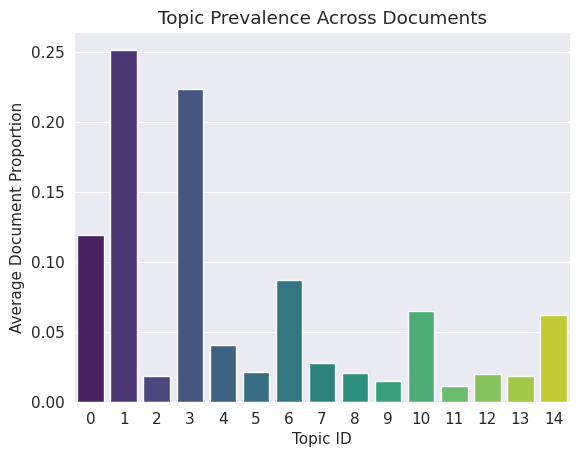

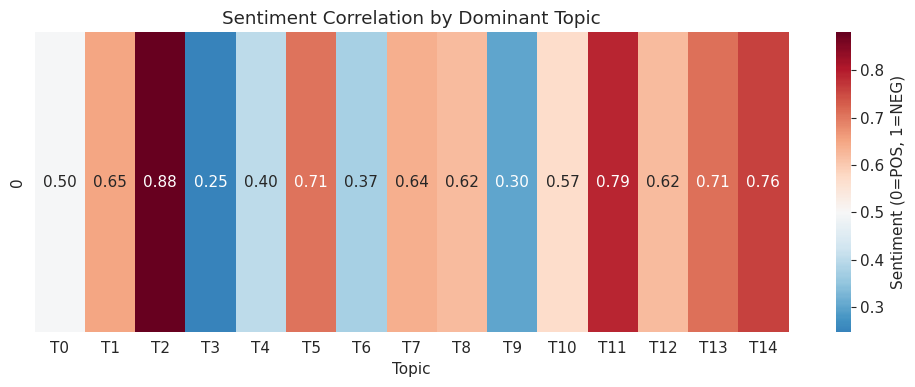

In [ ]:
# 1. Fix gensim_lda (convert sklearn LDA properly)
"""
from gensim.models import LdaModel
dictionary = Dictionary([vectorizer.get_feature_names_out()])
corpus = [dictionary.doc2bow(doc) for doc in vectors.toarray()]

# Use your sklearn LDA (don't retrain)
gensim_lda = LdaModel(id2word=dictionary, num_topics=n_topics)
gensim_lda.log_perplexity(corpus)  # dummy call to initialize

vis = gensimvis.prepare(gensim_lda, corpus, dictionary)
pyLDAvis.save_html(vis, 'lda_interactive.html')
"""

# 2. Fix barplot: use DataFrame
df_prevalence = pd.DataFrame({'prevalence': M.mean(axis=0)}, index=range(n_topics))
df_prevalence['topic'] = df_prevalence.index
sns.barplot(data=df_prevalence, x='topic', y='prevalence', palette='viridis')

plt.title('Topic Prevalence Across Documents')
plt.xlabel('Topic ID')
plt.ylabel('Average Document Proportion')
plt.savefig(f'lda_{DATASET}_prevalence.pdf', dpi=300, bbox_inches='tight')
plt.show()




# 3. Fix sentiment heatmap
dominant_topics = np.argmax(M, axis=1)
sentiment_by_topic = []
for i in range(n_topics):
    mask = dominant_topics == i
    if mask.sum() > 0:
        sentiment_by_topic.append(alllabs[mask].mean())
    else:
        sentiment_by_topic.append(0.5)

df_sentiment = pd.DataFrame({
    'topic': range(n_topics),
    'sentiment_correlation': sentiment_by_topic
})

plt.figure(figsize=(10, 4))
sns.heatmap(df_sentiment.set_index('topic')['sentiment_correlation'].values.reshape(1,-1), 
            annot=True, fmt='.2f', cmap='RdBu_r', center=0.5,
            xticklabels=[f'T{i}' for i in range(n_topics)],
            cbar_kws={'label': 'Sentiment (0=POS, 1=NEG)'})
plt.title('Sentiment Correlation by Dominant Topic')
plt.xlabel('Topic')
plt.tight_layout()
plt.savefig(f'lda_{DATASET}_sentiment_heatmap.pdf', dpi=300, bbox_inches='tight')
plt.show()

### PRES

In [32]:
from nltk.tokenize import RegexpTokenizer

#tokenizer = RegexpTokenizer(r'\w+')
n_topics = 15
vectorizer = CountVectorizer(
    lowercase=True, stop_words=STOPWORDS, ngram_range=(1,2),
    tokenizer=RegexpTokenizer(r'\w+').tokenize, 
    max_df=0.95, min_df=2, max_features=5000
)

vectors = vectorizer.fit_transform(alltxt)
lda = LatentDirichletAllocation(n_components=n_topics, random_state=42, max_iter=20)
M = lda.fit_transform(vectors)  # document-topic matrix (probabilities)

feat_names = vectorizer.get_feature_names_out()
for i, topic in enumerate(lda.components_):
    top_words = [feat_names[j] for j in np.argsort(topic)[-10:][::-1]]
    print(f"Topic {i}: {', '.join(top_words)}")

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(M)

scaler = StandardScaler()
M_scaled = scaler.fit_transform(M)
tsne = TSNE(n_components=2, perplexity=30, random_state=42,max_iter=2000)
tsne_mat = tsne.fit_transform(M_scaled)



/home/alant/repos/tal-projet/.venv/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Topic 0: tous, toutes, sécurité, ceux, français, paix, service, rendre, sous, action
Topic 1: faire, entreprises, faut, mieux, aussi, leurs, publics, services, pense, compte
Topic 2: a, tout, cela, peut, si, comme, là, où, être, dire
Topic 3: plus, chacun, entre, hommes, pays, femmes, chaque, enfants, monde, loin
Topic 4: politique, économique, développement, rôle, sociale, dialogue, social, cette, aussi, ambition
Topic 5: faut, première, deux, pris, guerre, trois, grande, depuis, fois, main
Topic 6: france, cette, européenne, union, a, pays, union européenne, europe, etats, date
Topic 7: tout, nom, dire, cette, aussi, voudrais, ici, tous, heure, français
Topic 8: hui, aujourd, aujourd hui, entre, pays, deux, sans, france, relations, doute
Topic 9: a, années, fait, depuis, progrès, pays, cours, longtemps, intérêt, ni
Topic 10: président, nom, monsieur, date, ans, monsieur président, a, messieurs, mesdames, mesdames messieurs
Topic 11: contre, internationale, oeuvre, aide, mise, dévelop

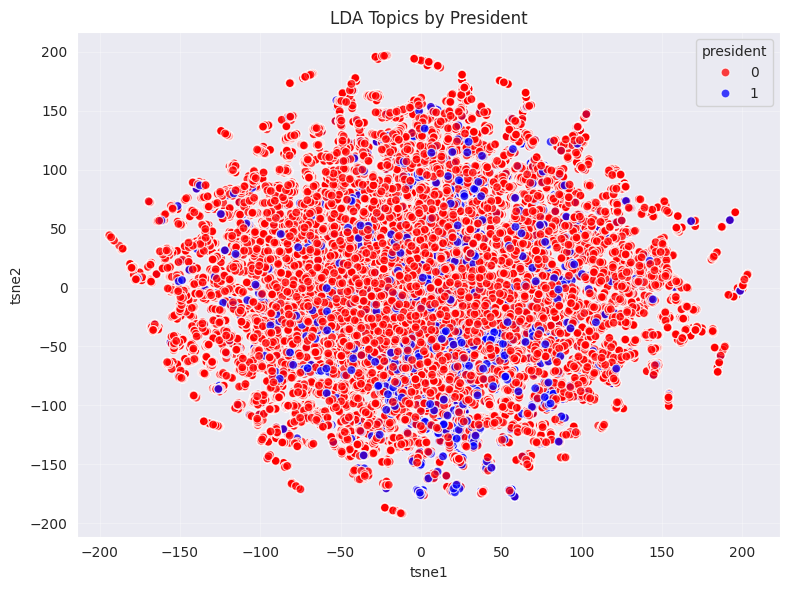

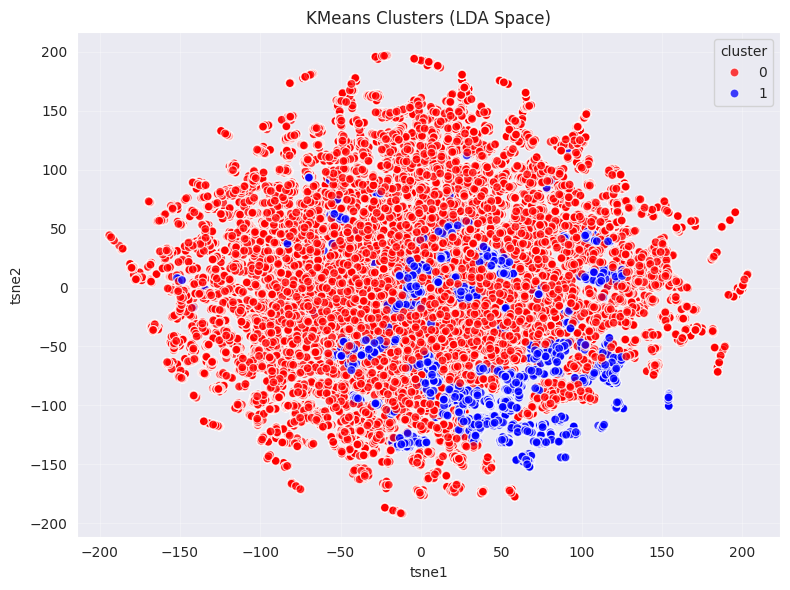

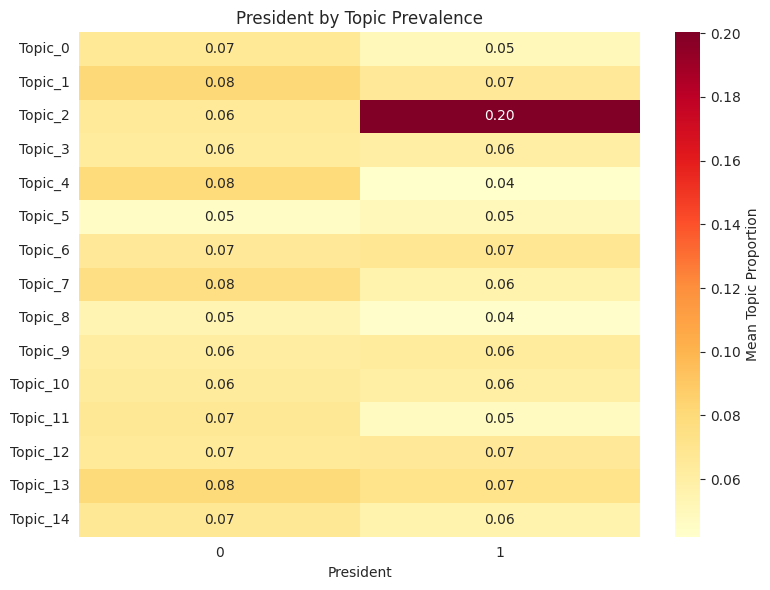

In [ ]:
df_vis = pd.DataFrame({
    'tsne1': tsne_mat[:, 0],
    'tsne2': tsne_mat[:, 1],
    'president': alllabs,
    'cluster': cluster_labels,
    'dominant_topic': np.argmax(M, axis=1)
})

fig, axes = plt.subplots(figsize=(8,6))

sns.scatterplot(data=df_vis, x='tsne1', y='tsne2', hue='president', 
                palette=['red', 'blue'], s=40, alpha=0.75,
                edgecolor='white', linewidth=0.8)
axes.set_title('LDA Topics by President')  
axes.grid(True, alpha=0.3)


plt.tight_layout()
plt.savefig(f'lda_{DATASET}_topics_speakers.pdf', dpi=300, bbox_inches='tight') 
plt.show()

fig, axes = plt.subplots(figsize=(8,6))


sns.scatterplot(data=df_vis, x='tsne1', y='tsne2', hue='cluster', 
                palette=['red', 'blue'], s=40, alpha=0.75, 
                edgecolor='white', linewidth=0.8)
axes.set_title('KMeans Clusters (LDA Space)')
axes.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'lda_{DATASET}_topics_kmeans.pdf', dpi=300, bbox_inches='tight')
plt.show()



fig, axes = plt.subplots(figsize=(8,6))

# Topic prevalence heatmap
topic_props = pd.DataFrame(M, columns=[f'Topic_{i}' for i in range(n_topics)])
topic_pres = topic_props.join(pd.Series(alllabs, name='president')).groupby('president')[topic_props.columns].mean()
sns.heatmap(topic_pres.T, annot=True, fmt='.2f', cmap='YlOrRd', 
            cbar_kws={'label': 'Mean Topic Proportion'})
axes.set_title('President by Topic Prevalence')
axes.set_xlabel('President')

plt.tight_layout()
plt.savefig(f'lda_{DATASET}_president_topic.pdf', dpi=300, bbox_inches='tight')
plt.show()


/tmp/ipykernel_70032/813252787.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_prevalence, x='topic', y='prevalence', palette='viridis')


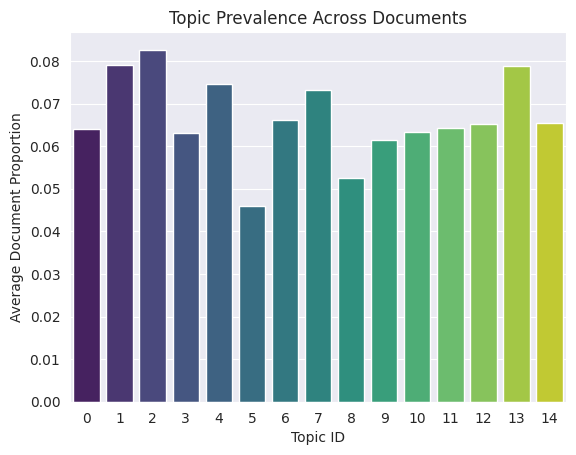

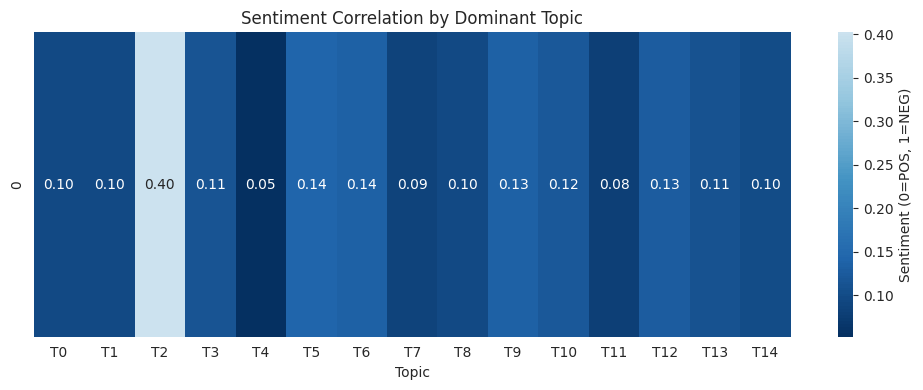

In [34]:
# 1. Fix gensim_lda (convert sklearn LDA properly)
"""
from gensim.models import LdaModel
dictionary = Dictionary([vectorizer.get_feature_names_out()])
corpus = [dictionary.doc2bow(doc) for doc in vectors.toarray()]

# Use your sklearn LDA (don't retrain)
gensim_lda = LdaModel(id2word=dictionary, num_topics=n_topics)
gensim_lda.log_perplexity(corpus)  # dummy call to initialize

vis = gensimvis.prepare(gensim_lda, corpus, dictionary)
pyLDAvis.save_html(vis, 'lda_interactive.html')
"""

# 2. Fix barplot: use DataFrame
df_prevalence = pd.DataFrame({'prevalence': M.mean(axis=0)}, index=range(n_topics))
df_prevalence['topic'] = df_prevalence.index
sns.barplot(data=df_prevalence, x='topic', y='prevalence', palette='viridis')

plt.title('Topic Prevalence Across Documents')
plt.xlabel('Topic ID')
plt.ylabel('Average Document Proportion')
plt.savefig(f'lda_{DATASET}_prevalence.pdf', dpi=300, bbox_inches='tight')
plt.show()




# 3. Fix sentiment heatmap
dominant_topics = np.argmax(M, axis=1)
sentiment_by_topic = []
for i in range(n_topics):
    mask = dominant_topics == i
    if mask.sum() > 0:
        sentiment_by_topic.append(alllabs[mask].mean())
    else:
        sentiment_by_topic.append(0.5)

df_sentiment = pd.DataFrame({
    'topic': range(n_topics),
    'sentiment_correlation': sentiment_by_topic
})

plt.figure(figsize=(10, 4))
sns.heatmap(df_sentiment.set_index('topic')['sentiment_correlation'].values.reshape(1,-1), 
            annot=True, fmt='.2f', cmap='RdBu_r', center=0.5,
            xticklabels=[f'T{i}' for i in range(n_topics)],
            cbar_kws={'label': 'Sentiment (0=POS, 1=NEG)'})
plt.title('Sentiment Correlation by Dominant Topic')
plt.xlabel('Topic')
plt.tight_layout()
plt.savefig(f'lda_{DATASET}_sentiment_heatmap.pdf', dpi=300, bbox_inches='tight')
plt.show()

# vocab vis

In [35]:
from gensim.models import Word2Vec
Preprocessing
#sns.set_style("whitegrid")
#plt.rcParams.update({'font.size': 11, 'font.family': 'sans-serif'})

punc = set(string.punctuation + '\n\r\t')
punc.remove("'") # keep the ' for french words 
custom_punctuation = "".join(punc)

prep = Preprocessing(low_case = True,
                rm_punctuation = True,
                rm_number = False,
                word_norm = None, # stem faster
                pos_tagging = False, # to check
                all_capital = True, # keep all capital words as they are
                cap_name = True, # garder les noms en majuscules, for pos tag
                rm_accent = False, 
                lang = "english" if DATASET == "movies" else "french",
                punct = custom_punctuation, # punctuation can contain -, that would be kept
                urls = False 
                )

def stopwords_rmv(text, stopwords=STOPWORDS):
    return " ".join([word for word in text.split() if word not in stopwords])

text = [stopwords_rmv(t) for t in alltxt]
text = [prep(t).split() for t in text]

w2v = Word2Vec(
    sentences=text,
    vector_size=100, 
    window=5,
    min_count=5,
    sg=1,           # Skip-gram (better for rare words)
    epochs=10,
    workers=4
)
w2v.save(f"w2v_{DATASET}.dat")

w2v = Word2Vec.load(f"w2v_{DATASET}.dat")

# select top 200 most frequent words
words = list(w2v.wv.index_to_key)[:100]
embeddings = np.array([w2v.wv[word] for word in words])

tsne = TSNE(n_components=2, perplexity=20, random_state=42, max_iter=3000)
embeddings_2d = tsne.fit_transform(embeddings)


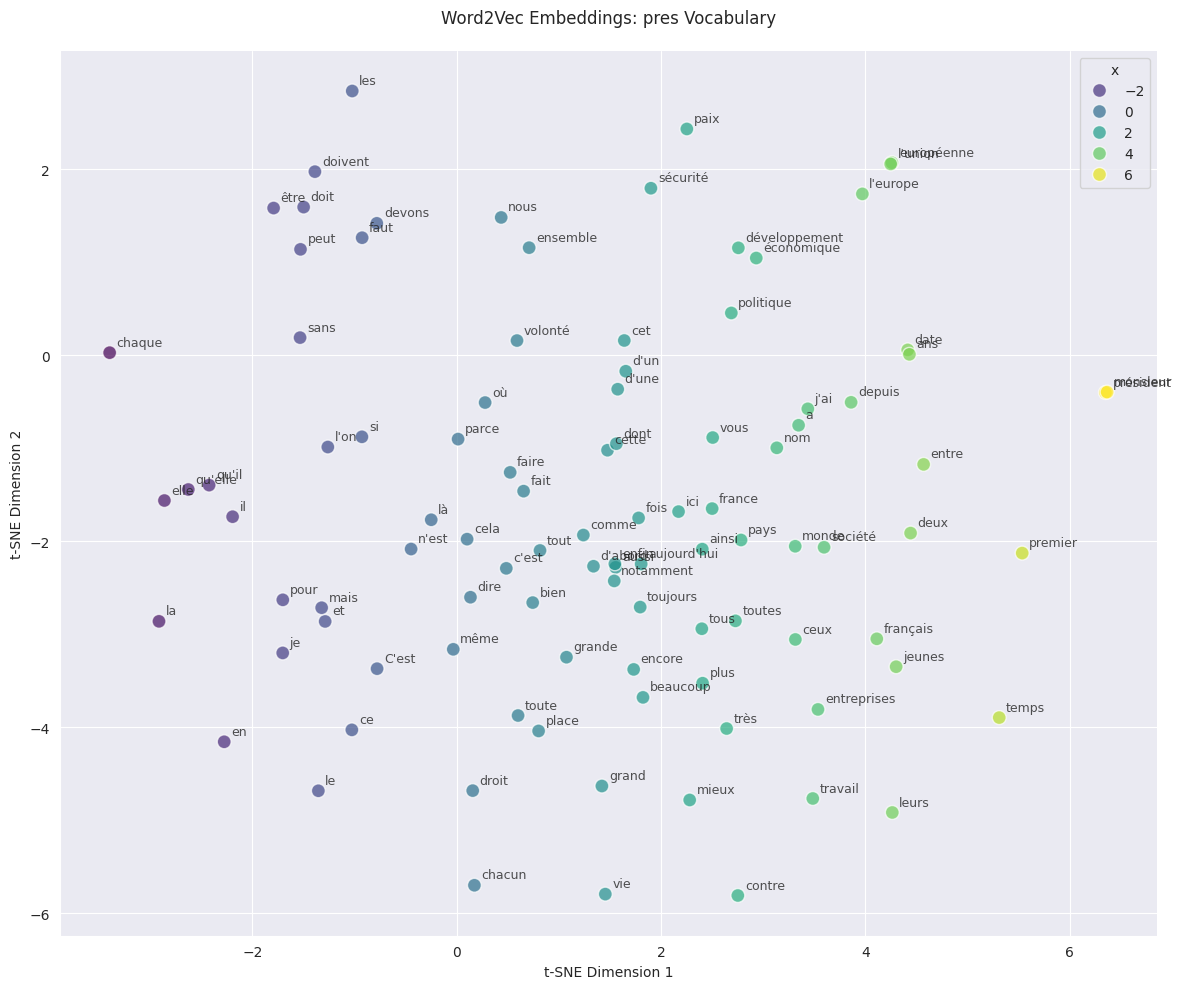

In [36]:
df_words = pd.DataFrame({
    'x': embeddings_2d[:, 0],
    'y': embeddings_2d[:, 1],
    'word': words
})

plt.figure(figsize=(12, 10))
sns.scatterplot(data=df_words, x='x', y='y', s=100, alpha=0.7, 
                edgecolor='white', linewidth=1, hue='x', palette='viridis')

for i, row in df_words.iterrows():
    plt.annotate(row['word'], (row['x'], row['y']), 
                xytext=(5, 5), textcoords='offset points',
                fontsize=9, alpha=0.8, ha='left')

plt.title(f'Word2Vec Embeddings: {DATASET} Vocabulary', pad=20)
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
sns.despine()
plt.tight_layout()
plt.savefig(f'w2v_{DATASET}_embeddings.pdf', dpi=300, bbox_inches='tight')
plt.show()